# Sinhala Fake News Detection — All-Mode Comparison

**Goal:** Compare all combinations of embedding methods × model architectures.

| Embedding Method | Dim | Architectures |
|-----------------|:---:|:---:|
| FastText (trained on corpus) | 100 | TextCNN, LSTM, BiLSTM, GRU |
| mBERT (frozen, token-level) | 768 | TextCNN, LSTM, BiLSTM, GRU |
| XLM-R (frozen, token-level) | 768 | TextCNN, LSTM, BiLSTM, GRU |

Total: **12 model configurations** — find the best combination and save it.

In [4]:
!pip install transformers gensim

## Setup — Imports, Device, Seed & Data Loading

In [5]:
import os, re, unicodedata, pickle, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_recall_fscore_support)
from gensim.models import FastText

from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
# ── Load raw data (repairing rows where source_type is missing) ───────────────
DATE_RE = re.compile(r'^\d{1,2}/\d{1,2}/\d{4}')

def read_clean(path):
    df = pd.read_csv(path, usecols=['source_type', 'datestamp', 'content'])
    # Some rows lack source_type, so the date lands in source_type and the
    # article text lands in datestamp. Detect and realign them, leaving
    # source_type empty.
    misaligned = df['source_type'].astype(str).str.match(DATE_RE, na=False)
    df.loc[misaligned, 'content'] = df.loc[misaligned, 'datestamp']
    df.loc[misaligned, 'datestamp'] = df.loc[misaligned, 'source_type']
    df.loc[misaligned, 'source_type'] = ''
    return df.drop(columns=['datestamp'])

true_df  = read_clean('TRUE.csv')
false_df = read_clean('FALSE.csv')

true_df['label']  = 1
false_df['label'] = 0

df = pd.concat([true_df, false_df], ignore_index=True)
df.dropna(subset=['content'], inplace=True)
df['content'] = df['content'].astype(str)

print(f"Total articles : {len(df)}")
print(f"True News      : {(df['label']==1).sum()}")
print(f"False News     : {(df['label']==0).sum()}")

# ── Text cleaning ──────────────────────────────────────────────────────────────
def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)

def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text)

def remove_special_chars(text):
    cleaned = re.sub(r'[^\u0D80-\u0DFF\u200C\u200D\s\w]', ' ', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

def clean_text(text):
    text = remove_urls(text)
    text = remove_emojis(text)
    text = remove_special_chars(text)
    return text

df['cleaned'] = df['content'].apply(clean_text)
print(f"\nCleaned {len(df)} articles.")

Total articles : 1960
True News      : 1052
False News     : 908

Cleaned 1960 articles.


In [7]:
# ── Data Cleaning — Before vs After ────────────────────────────────────────────
print("=" * 70)
print("DATA CLEANING — BEFORE vs AFTER (Sample Rows)")
print("=" * 70)

samples = df['content'].iloc[:3].tolist()
cleaned = df['cleaned'].iloc[:3].tolist()

for i, (raw, clean) in enumerate(zip(samples, cleaned)):
    print(f"\n--- Sample {i+1} ---")
    print(f"  BEFORE ({len(raw)} chars): {raw[:200]}{'...' if len(raw) > 200 else ''}")
    print(f"  AFTER  ({len(clean)} chars): {clean[:200]}{'...' if len(clean) > 200 else ''}")

# Stats
before_lens = df['content'].str.len()
after_lens = df['cleaned'].str.len()
print(f"\n--- Length Reduction Stats ---")
print(f"  Avg length BEFORE: {before_lens.mean():.1f} chars")
print(f"  Avg length AFTER:  {after_lens.mean():.1f} chars")
print(f"  Avg reduction:     {(before_lens.mean() - after_lens.mean()):.1f} chars")
print(f"  Articles where length changed: {(before_lens != after_lens).sum()} / {len(df)}")

DATA CLEANING — BEFORE vs AFTER (Sample Rows)

--- Sample 1 ---
  BEFORE (140 chars): මට්ටකුළිය,මෝදර, බ්ලූමැන්ඩල්, වැල්ලම්පිටිය, ග්‍රෑන්ඩ්පාස් පොලිස් බලප්‍රදේශ 05 සඳහා වහාම ක්‍රියාත්මක වන පරිදි පොලිස් ඇඳිරි නීතිය පනවා තිබෙනවා.
  AFTER  (136 chars): මට්ටකුළිය මෝදර බ්ලූමැන්ඩල් වැල්ලම්පිටිය ග්‍රෑන්ඩ්පාස් පොලිස් බලප්‍රදේශ 05 සඳහා වහාම ක්‍රියාත්මක වන පරිදි පොලිස් ඇඳිරි නීතිය පනවා තිබෙනවා

--- Sample 2 ---
  BEFORE (527 chars): නිරෝධායන ඇඳිරි නීතිය ක්‍රියාත්මක සමයේ බස්නාහිර පළාතට ඇතුළුවන සෑම ස්ථානයකම විශේෂ පොලිස් මාර්ග බාධක යොදවන බව පොලිස් මාධ්‍ය ප්‍රකාශක නියෝජ්‍ය පොලිස්පති අජිත් රෝහණ සඳහන් කළේය.ඒ අනුව නිරෝධායන ඇඳිරි නීතිය ...
  AFTER  (521 chars): නිරෝධායන ඇඳිරි නීතිය ක්‍රියාත්මක සමයේ බස්නාහිර පළාතට ඇතුළුවන සෑම ස්ථානයකම විශේෂ පොලිස් මාර්ග බාධක යොදවන බව පොලිස් මාධ්‍ය ප්‍රකාශක නියෝජ්‍ය පොලිස්පති අජිත් රෝහණ සඳහන් කළේය ඒ අනුව නිරෝධායන ඇඳිරි නීතිය ...

--- Sample 3 ---
  BEFORE (642 chars): නිරෝධායන ඇඳිරිනීතිය පැනවීම හේතුවෙන් ජිවනෝපාය අහිමි වූ ගම්පහ දිස්ත්‍රික්කයේ පවුල් සඳහා රුපියල් 5000 දිමනා

In [8]:
# ── Sinhala stop words ─────────────────────────────────────────────────────────
SINHALA_STOPWORDS = {
    '\u0dc3\u0dc4', '\u0dc4\u0dcf', '\u0dc4\u0ddd', '\u0db1\u0db8\u0dd4\u0dad\u0dca', '\u0d91\u0dc4\u0dd9\u0dad\u0dca',
    '\u0db1\u0dd2\u0dc3\u0dcf', '\u0db6\u0dd0\u0dc0\u0dd2\u0db1\u0dca', '\u0db1\u0db8\u0dca',
    '\u0db8\u0dd9\u0db8', '\u0d92', '\u0d91\u0db8', '\u0d91\u0dba', '\u0db8\u0dd9\u0dba',
    '\u0d94\u0dc4\u0dd4', '\u0d87\u0dba', '\u0d94\u0dc0\u0dd4\u0db1\u0dca', '\u0d94\u0dc0\u0dd4\u0dc4\u0dd4',
    '\u0d94\u0dc4\u0dd4\u0d9c\u0dda', '\u0d87\u0d9c\u0dda', '\u0d94\u0dc0\u0dd4\u0db1\u0dca\u0d9c\u0dda',
    '\u0db8\u0dd9\u0dc4\u0dd2', '\u0d91\u0dc4\u0dd2', '\u0db8\u0dd9\u0dad\u0dd0\u0db1', '\u0d91\u0dad\u0dd0\u0db1',
    '\u0daf', '\u0db8', '\u0dad\u0dca', '\u0dc0\u0dd9\u0dad', '\u0dc0\u0dd2\u0dc3\u0dd2\u0db1\u0dca',
    '\u0dc3\u0db3\u0dc4\u0dcf', '\u0d85\u0dad\u0dbb', '\u0db4\u0dd2\u0dc5\u0dd2\u0db6\u0db3', '\u0dbd\u0dd9\u0dc3',
    '\u0dbd\u0dd9\u0dc3\u0db8', '\u0dbd\u0dd9\u0dc3\u0dd2\u0db1\u0dca', '\u0d9a\u0dd9\u0dc3\u0dda',
    '\u0dba\u0db1\u0dd4', '\u0dba\u0db1', '\u0db6\u0dc0', '\u0dba\u0dba\u0dd2', '\u0d9a\u0dd2\u0dc0',
    '\u0dc0\u0dda', '\u0dc0\u0dd9\u0dba\u0dd2', '\u0d87\u0dad', '\u0db1\u0dd0\u0dad', '\u0d87\u0dad\u0dd2',
    '\u0db1\u0dd0\u0dad\u0dd2', '\u0dc0\u0dd2\u0dba', '\u0dc0\u0dd3', '\u0d9a\u0dbb', '\u0d9a\u0dc5',
    '\u0d9a\u0dbb\u0dba\u0dd2', '\u0d9a\u0dbb\u0db1\u0dd4', '\u0d9a\u0dbb\u0db1', '\u0dbd\u0db6\u0dcf',
    '\u0dbd\u0dd0\u0db6\u0dd3', '\u0dbd\u0dd0\u0db6\u0dd9\u0db1', '\u0daf\u0dd3', '\u0d9c\u0dd9\u0db1', '\u0d9c\u0ddc\u0dc3\u0dca',
    '\u0dad\u0dd4\u0dc5', '\u0dc3\u0dd2\u0da7', '\u0daf\u0d9a\u0dca\u0dc0\u0dcf', '\u0db4\u0dd2\u0da7',
    '\u0d85\u0db1\u0dd4\u0dc0', '\u0dba\u0da7\u0dad\u0dda', '\u0dc4\u0dbb\u0dc4\u0dcf',
    '\u0d91\u0d9a\u0d9a\u0dca', '\u0daf\u0dd9\u0d9a\u0d9a\u0dca', '\u0d9a\u0dd2\u0dc4\u0dd2\u0db4\u0dba\u0d9a\u0dca',
    '\u0dc3\u0dd2\u0dba\u0dbd\u0dd4', '\u0dc3\u0dd1\u0db8', '\u0d87\u0dad\u0dd0\u0db8\u0dca', '\u0db6\u0ddc\u0dc4\u0ddd',
    '\u0d9a\u0dc0\u0dd4\u0daf', '\u0d9a\u0dd4\u0db8\u0d9a\u0dca\u0daf', '\u0d9a\u0ddc\u0dad\u0dd9\u0d9a\u0daf',
    '\u0d9a\u0dd9\u0dc3\u0dda\u0daf', '\u0d87\u0dba\u0dd2', '\u0d9a\u0dc0\u0daf\u0dcf',
    '\u0db8\u0dd9\u0dbd\u0dd9\u0dc3', '\u0d92', '\u0dc0\u0db1', '\u0dc0\u0dd6', '\u0dba\u0dd0\u0dba\u0dd2',
    '\u0d89\u0daf\u0dd2\u0dbb\u0dd2\u0db4\u0dad\u0dca', '\u0db4\u0dca\u200d\u0dbb\u0d9a\u0dcf\u0dc1',
}

def tokenize(text):
    tokens = text.split()
    return [t for t in tokens
            if re.fullmatch(r'[\u0D80-\u0DFF\u200C\u200D]+', t) and len(t) >= 2]

def remove_stopwords(tokens):
    return [t for t in tokens if t not in SINHALA_STOPWORDS]

def tokenize_and_filter(text):
    tokens = tokenize(text)
    return remove_stopwords(tokens)

df['tokens'] = df['cleaned'].apply(tokenize_and_filter)

# ── Unicode normalization ──────────────────────────────────────────────────────
def normalize_sinhala(tokens):
    return [unicodedata.normalize('NFC', t) for t in tokens]

def fix_zwj(token):
    return token.strip('\u200C\u200D')

def full_normalize(tokens):
    tokens = normalize_sinhala(tokens)
    tokens = [fix_zwj(t) for t in tokens]
    return [t for t in tokens if len(t) >= 2]

df['tokens_norm'] = df['tokens'].apply(full_normalize)

lengths = df['tokens_norm'].apply(len)
print(f"Avg tokens per article : {lengths.mean():.1f}")
print(f"Max tokens             : {lengths.max()}")

MAX_SEQ_LEN = 150

Avg tokens per article : 99.3
Max tokens             : 1435


In [9]:
# ── Tokenization & Normalization — Pipeline Preview ────────────────────────────
print("=" * 70)
print("TOKENIZATION PIPELINE — Sample Articles (Cleaned → Tokens → Normalized)")
print("=" * 70)

for i in range(3):
    cleaned_text = df['cleaned'].iloc[i]
    tokens_raw = df['tokens'].iloc[i]
    tokens_norm = df['tokens_norm'].iloc[i]

    print(f"\n--- Sample {i+1} ---")
    print(f"  CLEANED TEXT (first 150 chars): {cleaned_text[:150]}...")
    print(f"  AFTER TOKENIZE + STOPWORD REMOVAL: [{len(tokens_raw)} tokens] "
          f"{tokens_raw[:15]}{' ...' if len(tokens_raw) > 15 else ''}")
    print(f"  AFTER UNICODE NORM (NFC+ZWJ fix):  [{len(tokens_norm)} tokens] "
          f"{tokens_norm[:15]}{' ...' if len(tokens_norm) > 15 else ''}")

print(f"\n--- Token Length Distribution ---")
print(f"  Min tokens: {df['tokens_norm'].apply(len).min()}")
print(f"  Max tokens: {df['tokens_norm'].apply(len).max()}")
print(f"  Mean tokens: {df['tokens_norm'].apply(len).mean():.1f}")
print(f"  Median tokens: {df['tokens_norm'].apply(len).median():.0f}")

# Stop words removed count
total_before = df['tokens'].apply(len).sum()
total_after = df['tokens_norm'].apply(len).sum()
print(f"\n--- Stop Word & Normalization Impact ---")
print(f"  Total tokens before normalization: {total_before}")
print(f"  Total tokens after normalization:  {total_after}")
print(f"  Tokens removed (stop words + short/fixes): {total_before - total_after}")

TOKENIZATION PIPELINE — Sample Articles (Cleaned → Tokens → Normalized)

--- Sample 1 ---
  CLEANED TEXT (first 150 chars): මට්ටකුළිය මෝදර බ්ලූමැන්ඩල් වැල්ලම්පිටිය ග්‍රෑන්ඩ්පාස් පොලිස් බලප්‍රදේශ 05 සඳහා වහාම ක්‍රියාත්මක වන පරිදි පොලිස් ඇඳිරි නීතිය පනවා තිබෙනවා...
  AFTER TOKENIZE + STOPWORD REMOVAL: [15 tokens] ['මට්ටකුළිය', 'මෝදර', 'බ්ලූමැන්ඩල්', 'වැල්ලම්පිටිය', 'ග්\u200dරෑන්ඩ්පාස්', 'පොලිස්', 'බලප්\u200dරදේශ', 'වහාම', 'ක්\u200dරියාත්මක', 'පරිදි', 'පොලිස්', 'ඇඳිරි', 'නීතිය', 'පනවා', 'තිබෙනවා']
  AFTER UNICODE NORM (NFC+ZWJ fix):  [15 tokens] ['මට්ටකුළිය', 'මෝදර', 'බ්ලූමැන්ඩල්', 'වැල්ලම්පිටිය', 'ග්\u200dරෑන්ඩ්පාස්', 'පොලිස්', 'බලප්\u200dරදේශ', 'වහාම', 'ක්\u200dරියාත්මක', 'පරිදි', 'පොලිස්', 'ඇඳිරි', 'නීතිය', 'පනවා', 'තිබෙනවා']

--- Sample 2 ---
  CLEANED TEXT (first 150 chars): නිරෝධායන ඇඳිරි නීතිය ක්‍රියාත්මක සමයේ බස්නාහිර පළාතට ඇතුළුවන සෑම ස්ථානයකම විශේෂ පොලිස් මාර්ග බාධක යොදවන බව පොලිස් මාධ්‍ය ප්‍රකාශක නියෝජ්‍ය පොලිස්පති ...
  AFTER TOKENIZE + STOPWORD REMOVAL: [69 tokens] ['නිරෝධාය

---
## Shared Components — Dataset, Training Loop, & All Architecture Definitions

These are reused across all 12 combinations.

In [10]:
# ── Dataset: auto-detects bool/int (token IDs) vs float (pre-computed embeddings) ──
class NewsDataset(Dataset):
    def __init__(self, X, y):
        dtype = torch.long if X.dtype in (np.int32, np.int64, np.int_, np.bool_) else torch.float32
        self.X = torch.tensor(X, dtype=dtype)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [11]:
# ────────────────────────────────────────────────────────────────────────────────
# Architecture 1: TextCNN (token-ID input, static embedding lookup)
# ────────────────────────────────────────────────────────────────────────────────
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix,
                 num_classes=2, num_filters=96,
                 kernel_sizes=(2, 3, 4), dropout=0.65,
                 emb_dropout=0.25, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight = nn.Parameter(torch.tensor(embed_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k-1) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x)               # (batch, seq, embed)
        emb = self.emb_dropout(emb)
        emb = emb.permute(0, 2, 1)            # (batch, embed, seq)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(emb))
            c = F.max_pool1d(c, c.shape[2]).squeeze(2)
            pooled.append(c)
        cat = torch.cat(pooled, dim=1)
        out = self.fc(self.dropout(cat))
        return out

# ────────────────────────────────────────────────────────────────────────────────
# Architecture 2: LSTM (token-ID input)
# ────────────────────────────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix,
                 hidden_dim=128, num_layers=2, num_classes=2,
                 dropout=0.5, emb_dropout=0.25, pad_idx=0,
                 bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight = nn.Parameter(torch.tensor(embed_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.emb_dropout = nn.Dropout(emb_dropout)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )
        n_directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * n_directions, num_classes)

    def forward(self, x):
        emb = self.embedding(x)               # (batch, seq, embed)
        emb = self.emb_dropout(emb)
        out, (hn, cn) = self.lstm(emb)
        # Use last-layer hidden state
        if self.lstm.bidirectional:
            last = torch.cat((hn[-2], hn[-1]), dim=1)  # (batch, 2*hidden)
        else:
            last = hn[-1]                              # (batch, hidden)
        out = self.fc(self.dropout(last))
        return out

# ────────────────────────────────────────────────────────────────────────────────
# Architecture 3: BiLSTM (token-ID input) — just LSTM with bidirectional=True
# ────────────────────────────────────────────────────────────────────────────────
# (Same as LSTMClassifier(bidirectional=True))

# ────────────────────────────────────────────────────────────────────────────────
# Architecture 4: GRU (token-ID input)
# ────────────────────────────────────────────────────────────────────────────────
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, embed_matrix,
                 hidden_dim=128, num_layers=2, num_classes=2,
                 dropout=0.5, emb_dropout=0.25, pad_idx=0,
                 bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.embedding.weight = nn.Parameter(torch.tensor(embed_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.emb_dropout = nn.Dropout(emb_dropout)

        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )
        n_directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * n_directions, num_classes)

    def forward(self, x):
        emb = self.embedding(x)               # (batch, seq, embed)
        emb = self.emb_dropout(emb)
        out, hn = self.gru(emb)
        if self.gru.bidirectional:
            last = torch.cat((hn[-2], hn[-1]), dim=1)
        else:
            last = hn[-1]
        out = self.fc(self.dropout(last))
        return out

# ────────────────────────────────────────────────────────────────────────────────
# Pre-Embed Versions (for mBERT / XLM-R frozen embeddings)
# ────────────────────────────────────────────────────────────────────────────────

class TextCNNPreEmbed(nn.Module):
    """TextCNN accepting pre-computed embeddings (batch, seq, embed_dim)."""
    def __init__(self, embed_dim, num_classes=2, num_filters=96,
                 kernel_sizes=(2, 3, 4), dropout=0.65, emb_dropout=0.25):
        super().__init__()
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k-1) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.emb_dropout(x)
        x = x.permute(0, 2, 1)  # (batch, embed, seq)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x))
            c = F.max_pool1d(c, c.shape[2]).squeeze(2)
            pooled.append(c)
        cat = torch.cat(pooled, dim=1)
        out = self.fc(self.dropout(cat))
        return out


class LSTMClassifierPreEmbed(nn.Module):
    """LSTM accepting pre-computed embeddings (batch, seq, embed_dim)."""
    def __init__(self, embed_dim, hidden_dim=128, num_layers=2,
                 num_classes=2, dropout=0.5, emb_dropout=0.25,
                 bidirectional=False):
        super().__init__()
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )
        n_directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * n_directions, num_classes)

    def forward(self, x):
        x = self.emb_dropout(x)               # (batch, seq, embed)
        out, (hn, cn) = self.lstm(x)
        if self.lstm.bidirectional:
            last = torch.cat((hn[-2], hn[-1]), dim=1)
        else:
            last = hn[-1]
        out = self.fc(self.dropout(last))
        return out


class GRUClassifierPreEmbed(nn.Module):
    """GRU accepting pre-computed embeddings (batch, seq, embed_dim)."""
    def __init__(self, embed_dim, hidden_dim=128, num_layers=2,
                 num_classes=2, dropout=0.5, emb_dropout=0.25,
                 bidirectional=False):
        super().__init__()
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )
        n_directions = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * n_directions, num_classes)

    def forward(self, x):
        x = self.emb_dropout(x)
        out, hn = self.gru(x)
        if self.gru.bidirectional:
            last = torch.cat((hn[-2], hn[-1]), dim=1)
        else:
            last = hn[-1]
        out = self.fc(self.dropout(last))
        return out

print("All architectures defined.")

All architectures defined.


In [12]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=40, batch_size=32, patience=10,
                lr=7e-4, weight_decay=1e-3, label_smoothing=0.08,
                model_name='model'):
    """Generic training loop. Returns (model, history, best_epoch)."""
    train_ds = NewsDataset(X_train, y_train)
    val_ds   = NewsDataset(X_val, y_val)

    train_class_counts = np.bincount(y_train)
    class_sample_weight = 1.0 / train_class_counts
    sample_weights = np.array([class_sample_weight[c] for c in y_train], dtype=np.float32)
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(sample_weights), replacement=True,
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=4, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item() * len(yb)
            t_correct += (out.argmax(1) == yb).sum().item()

        model.eval()
        v_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * len(yb)
                v_correct += (out.argmax(1) == yb).sum().item()

        t_loss /= len(X_train)
        v_loss /= len(X_val)
        t_acc = t_correct / len(X_train)
        v_acc = v_correct / len(X_val)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        scheduler.step(v_loss)

        if v_loss < best_val_loss - 1e-4:
            best_val_loss = v_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            gap = (t_acc - v_acc) * 100
            print(f"  {model_name}: Epoch {epoch:3d}/{epochs} | TrL {t_loss:.4f} TrA {t_acc*100:.1f}% | "
                  f"VaL {v_loss:.4f} VaA {v_acc*100:.1f}% | Gap {gap:+.1f}%")

        if no_improve >= patience:
            print(f"  {model_name}: Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  {model_name}: Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    return model, history, best_epoch


def evaluate_model(model, X_test, y_test, batch_size=32):
    """Evaluate on test set, return (y_true, y_pred, y_prob)."""
    test_ds = NewsDataset(X_test, y_test)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_true.extend(yb.numpy())
    return np.array(all_true), np.array(all_preds), np.array(all_probs)


print("Training function and evaluation helper defined.")

Training function and evaluation helper defined.


---
## Section 1: FastText Embeddings (Dim=100)

In [13]:
EMBED_DIM_FT = 100

# ── Train FastText ──────────────────────────────────────────────────────────────
corpus = df['tokens_norm'].tolist()
print("Training FastText...")
ft_model = FastText(
    sentences=corpus,
    vector_size=EMBED_DIM_FT,
    window=5,
    min_count=1,
    workers=4,
    epochs=30,
    sg=1,
    seed=SEED,
)
print(f"FastText vocab size: {len(ft_model.wv):,}")

# ── Build vocab & embedding matrix ─────────────────────────────────────────────
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

all_tokens = [t for toks in df['tokens_norm'] for t in toks]
vocab_counts = Counter(all_tokens)
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, _ in vocab_counts.most_common()]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
PAD_IDX = word2idx[PAD_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]
print(f"Vocabulary size: {VOCAB_SIZE:,}")

embed_matrix_ft = np.zeros((VOCAB_SIZE, EMBED_DIM_FT), dtype=np.float32)
for word, idx in word2idx.items():
    if word in ft_model.wv:
        embed_matrix_ft[idx] = ft_model.wv[word]

# ── Encode ─────────────────────────────────────────────────────────────────────
def encode(tokens, max_len):
    ids = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

df['encoded'] = df['tokens_norm'].apply(lambda t: encode(t, MAX_SEQ_LEN))
X = np.array(df['encoded'].tolist(), dtype=np.int64)
y = df['label'].values.astype(np.int64)

X_train_ft, X_temp, y_train_ft, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val_ft, X_test_ft, y_val_ft, y_test_ft = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train: {len(X_train_ft)} | Val: {len(X_val_ft)} | Test: {len(X_test_ft)}")

Training FastText...
FastText vocab size: 22,968
Vocabulary size: 22,970
Train: 1372 | Val: 294 | Test: 294


In [14]:
# ── Train all 4 architectures with FastText embeddings ─────────────────────────
ft_results = {}

configs_ft = [
    ('TextCNN',
     TextCNN(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM_FT,
             embed_matrix=embed_matrix_ft, pad_idx=PAD_IDX)),
    ('LSTM',
     LSTMClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM_FT,
                    embed_matrix=embed_matrix_ft, pad_idx=PAD_IDX,
                    bidirectional=False)),
    ('BiLSTM',
     LSTMClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM_FT,
                    embed_matrix=embed_matrix_ft, pad_idx=PAD_IDX,
                    bidirectional=True)),
    ('GRU',
     GRUClassifier(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM_FT,
                   embed_matrix=embed_matrix_ft, pad_idx=PAD_IDX,
                   bidirectional=False)),
]

for arch_name, model in configs_ft:
    print(f"\n{'='*60}")
    print(f"FastText + {arch_name}")
    print(f"{'='*60}")
    model, hist, best_ep = train_model(
        model, X_train_ft, y_train_ft, X_val_ft, y_val_ft,
        model_name=f'FT-{arch_name}',
    )
    yt, yp, yprob = evaluate_model(model, X_test_ft, y_test_ft)
    acc = accuracy_score(yt, yp)
    f1_macro = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    print(f"  >>> FastText+{arch_name}: Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}")
    ft_results[arch_name] = {
        'model': model, 'history': hist, 'best_epoch': best_ep,
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'y_true': yt, 'y_pred': yp, 'y_prob': yprob,
    }


FastText + TextCNN
  FT-TextCNN: Epoch   1/40 | TrL 0.6614 TrA 63.9% | VaL 0.5120 VaA 79.3% | Gap -15.3%
  FT-TextCNN: Epoch   5/40 | TrL 0.4124 TrA 85.9% | VaL 0.4383 VaA 82.3% | Gap +3.5%
  FT-TextCNN: Epoch  10/40 | TrL 0.3572 TrA 89.1% | VaL 0.4438 VaA 83.0% | Gap +6.1%
  FT-TextCNN: Epoch  15/40 | TrL 0.3161 TrA 92.1% | VaL 0.4110 VaA 84.7% | Gap +7.4%
  FT-TextCNN: Epoch  20/40 | TrL 0.2885 TrA 93.9% | VaL 0.3964 VaA 85.7% | Gap +8.2%
  FT-TextCNN: Epoch  25/40 | TrL 0.2700 TrA 94.4% | VaL 0.4002 VaA 84.7% | Gap +9.7%
  FT-TextCNN: Epoch  30/40 | TrL 0.2536 TrA 96.3% | VaL 0.3996 VaA 86.1% | Gap +10.2%
  FT-TextCNN: Early stopping at epoch 30
  FT-TextCNN: Best val loss: 0.3964 at epoch 20
  >>> FastText+TextCNN: Acc=82.99%  MacroF1=0.8279  WeightedF1=0.8293

FastText + LSTM
  FT-LSTM: Epoch   1/40 | TrL 0.6714 TrA 57.5% | VaL 0.6867 VaA 54.4% | Gap +3.1%
  FT-LSTM: Epoch   5/40 | TrL 0.6817 TrA 56.6% | VaL 0.6726 VaA 57.5% | Gap -0.9%
  FT-LSTM: Epoch  10/40 | TrL 0.5733 TrA 75

---
## Section 2: mBERT Embeddings (Dim=768)

In [15]:
print("Loading mBERT...")
mbert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
mbert_model = AutoModel.from_pretrained("bert-base-multilingual-cased")
mbert_model.eval()
mbert_model.to(DEVICE)
print(f"mBERT hidden size: {mbert_model.config.hidden_size}")
MBERT_DIM = mbert_model.config.hidden_size  # 768

# ── Pre-extract mBERT token-level embeddings ───────────────────────────────────
def extract_transformer_embeddings(texts, tokenizer, model, max_len=150):
    all_embs = []
    for text in texts:
        encoded = tokenizer(
            text,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = model(**encoded)
        emb = outputs.last_hidden_state.squeeze(0).cpu().numpy()
        all_embs.append(emb)
    return np.array(all_embs)

print("Extracting mBERT embeddings...")
t0 = time.time()
embeddings_mbert = extract_transformer_embeddings(
    df['cleaned'].tolist(), mbert_tokenizer, mbert_model, max_len=MAX_SEQ_LEN)
print(f"mBERT embeddings shape: {embeddings_mbert.shape}  ({time.time()-t0:.1f}s)")

Loading mBERT...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mBERT hidden size: 768
Extracting mBERT embeddings...
mBERT embeddings shape: (1960, 150, 768)  (27.2s)


In [16]:
# ── Same stratified split by index ─────────────────────────────────────────────
idx_train, idx_temp, _, _ = train_test_split(
    np.arange(len(df)), y, test_size=0.30, stratify=y, random_state=SEED)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y[idx_temp], test_size=0.50, stratify=y[idx_temp], random_state=SEED)

X_train_mb = embeddings_mbert[idx_train]
X_val_mb   = embeddings_mbert[idx_val]
X_test_mb  = embeddings_mbert[idx_test]
y_train_mb = y[idx_train]
y_val_mb   = y[idx_val]
y_test_mb  = y[idx_test]

In [17]:
# ── Train all 4 architectures with mBERT pre-computed embeddings ───────────────
mb_results = {}

configs_mb = [
    ('TextCNN', TextCNNPreEmbed(embed_dim=MBERT_DIM)),
    ('LSTM',    LSTMClassifierPreEmbed(embed_dim=MBERT_DIM, bidirectional=False)),
    ('BiLSTM',  LSTMClassifierPreEmbed(embed_dim=MBERT_DIM, bidirectional=True)),
    ('GRU',     GRUClassifierPreEmbed(embed_dim=MBERT_DIM, bidirectional=False)),
]

for arch_name, model in configs_mb:
    print(f"\n{'='*60}")
    print(f"mBERT + {arch_name}")
    print(f"{'='*60}")
    model, hist, best_ep = train_model(
        model, X_train_mb, y_train_mb, X_val_mb, y_val_mb,
        model_name=f'mBERT-{arch_name}',
    )
    yt, yp, yprob = evaluate_model(model, X_test_mb, y_test_mb)
    acc = accuracy_score(yt, yp)
    f1_macro = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    print(f"  >>> mBERT+{arch_name}: Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}")
    mb_results[arch_name] = {
        'model': model, 'history': hist, 'best_epoch': best_ep,
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'y_true': yt, 'y_pred': yp, 'y_prob': yprob,
    }


mBERT + TextCNN
  mBERT-TextCNN: Epoch   1/40 | TrL 0.7450 TrA 63.0% | VaL 0.5547 VaA 77.2% | Gap -14.2%
  mBERT-TextCNN: Epoch   5/40 | TrL 0.5376 TrA 77.4% | VaL 0.5185 VaA 80.3% | Gap -2.9%
  mBERT-TextCNN: Epoch  10/40 | TrL 0.4784 TrA 81.7% | VaL 0.5048 VaA 81.3% | Gap +0.4%
  mBERT-TextCNN: Epoch  15/40 | TrL 0.4576 TrA 84.0% | VaL 0.5137 VaA 81.6% | Gap +2.3%
  mBERT-TextCNN: Epoch  20/40 | TrL 0.4591 TrA 83.1% | VaL 0.4894 VaA 80.6% | Gap +2.5%
  mBERT-TextCNN: Epoch  25/40 | TrL 0.4403 TrA 85.3% | VaL 0.4965 VaA 82.0% | Gap +3.4%
  mBERT-TextCNN: Epoch  30/40 | TrL 0.4302 TrA 85.2% | VaL 0.4803 VaA 82.7% | Gap +2.6%
  mBERT-TextCNN: Epoch  35/40 | TrL 0.3995 TrA 86.9% | VaL 0.4779 VaA 83.0% | Gap +3.9%
  mBERT-TextCNN: Early stopping at epoch 36
  mBERT-TextCNN: Best val loss: 0.4712 at epoch 26
  >>> mBERT+TextCNN: Acc=80.95%  MacroF1=0.8069  WeightedF1=0.8086

mBERT + LSTM
  mBERT-LSTM: Epoch   1/40 | TrL 0.6071 TrA 69.8% | VaL 0.5487 VaA 77.9% | Gap -8.1%
  mBERT-LSTM: Epo

---
## Section 3: XLM-R Embeddings (Dim=768)

In [18]:
print("Loading XLM-R...")
xlmr_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
xlmr_model = AutoModel.from_pretrained("xlm-roberta-base")
xlmr_model.eval()
xlmr_model.to(DEVICE)
print(f"XLM-R hidden size: {xlmr_model.config.hidden_size}")
XLMR_DIM = xlmr_model.config.hidden_size  # 768

print("Extracting XLM-R embeddings...")
t0 = time.time()
embeddings_xlmr = extract_transformer_embeddings(
    df['cleaned'].tolist(), xlmr_tokenizer, xlmr_model, max_len=MAX_SEQ_LEN)
print(f"XLM-R embeddings shape: {embeddings_xlmr.shape}  ({time.time()-t0:.1f}s)")

Loading XLM-R...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLM-R hidden size: 768
Extracting XLM-R embeddings...
XLM-R embeddings shape: (1960, 150, 768)  (28.4s)


In [19]:
X_train_xr = embeddings_xlmr[idx_train]
X_val_xr   = embeddings_xlmr[idx_val]
X_test_xr  = embeddings_xlmr[idx_test]
y_train_xr = y[idx_train]
y_val_xr   = y[idx_val]
y_test_xr  = y[idx_test]

In [20]:
# ── Train all 4 architectures with XLM-R pre-computed embeddings ───────────────
xr_results = {}

configs_xr = [
    ('TextCNN', TextCNNPreEmbed(embed_dim=XLMR_DIM)),
    ('LSTM',    LSTMClassifierPreEmbed(embed_dim=XLMR_DIM, bidirectional=False)),
    ('BiLSTM',  LSTMClassifierPreEmbed(embed_dim=XLMR_DIM, bidirectional=True)),
    ('GRU',     GRUClassifierPreEmbed(embed_dim=XLMR_DIM, bidirectional=False)),
]

for arch_name, model in configs_xr:
    print(f"\n{'='*60}")
    print(f"XLM-R + {arch_name}")
    print(f"{'='*60}")
    model, hist, best_ep = train_model(
        model, X_train_xr, y_train_xr, X_val_xr, y_val_xr,
        model_name=f'XLM-R-{arch_name}',
    )
    yt, yp, yprob = evaluate_model(model, X_test_xr, y_test_xr)
    acc = accuracy_score(yt, yp)
    f1_macro = f1_score(yt, yp, average='macro')
    f1_weighted = f1_score(yt, yp, average='weighted')
    print(f"  >>> XLM-R+{arch_name}: Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}")
    xr_results[arch_name] = {
        'model': model, 'history': hist, 'best_epoch': best_ep,
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'y_true': yt, 'y_pred': yp, 'y_prob': yprob,
    }


XLM-R + TextCNN
  XLM-R-TextCNN: Epoch   1/40 | TrL 0.6652 TrA 64.9% | VaL 0.5845 VaA 78.9% | Gap -14.0%
  XLM-R-TextCNN: Epoch   5/40 | TrL 0.4311 TrA 85.0% | VaL 0.4482 VaA 82.3% | Gap +2.7%
  XLM-R-TextCNN: Epoch  10/40 | TrL 0.3587 TrA 90.3% | VaL 0.4251 VaA 83.0% | Gap +7.3%
  XLM-R-TextCNN: Epoch  15/40 | TrL 0.3115 TrA 91.8% | VaL 0.4201 VaA 85.0% | Gap +6.7%
  XLM-R-TextCNN: Epoch  20/40 | TrL 0.2586 TrA 96.3% | VaL 0.4279 VaA 86.1% | Gap +10.2%
  XLM-R-TextCNN: Early stopping at epoch 22
  XLM-R-TextCNN: Best val loss: 0.4121 at epoch 12
  >>> XLM-R+TextCNN: Acc=82.99%  MacroF1=0.8267  WeightedF1=0.8285

XLM-R + LSTM
  XLM-R-LSTM: Epoch   1/40 | TrL 0.6126 TrA 70.6% | VaL 0.5873 VaA 73.1% | Gap -2.5%
  XLM-R-LSTM: Epoch   5/40 | TrL 0.4911 TrA 81.6% | VaL 0.4631 VaA 83.7% | Gap -2.0%
  XLM-R-LSTM: Epoch  10/40 | TrL 0.4560 TrA 83.7% | VaL 0.4960 VaA 82.0% | Gap +1.8%
  XLM-R-LSTM: Epoch  15/40 | TrL 0.4482 TrA 84.6% | VaL 0.6890 VaA 75.5% | Gap +9.1%
  XLM-R-LSTM: Epoch  20/4

## Section 4: Transformer Fine-Tuning (mBERT / XLM-R)

Instead of using frozen embeddings, the transformer backbones are now **fine-tuned end-to-end** (all parameters trainable) with a small classification head, using a low learning rate (2e-5), the same stratified 70/15/15 split, weighted sampling for class balance, and early stopping on validation loss.

In [21]:
# ── Transformer fine-tuning helpers ────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

class TransformerDataset(Dataset):
    """Dataset for fine-tuning: tokenized input_ids + attention_mask."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[i], dtype=torch.long),
        }

def finetune_transformer(model, tokenizer, X_text, y_tr, Xv_text, y_vl,
                         epochs=12, batch_size=8, patience=4,
                         lr=2e-5, weight_decay=1e-4, model_name='transformer'):
    """Fine-tune a transformer end-to-end (all parameters trainable)."""
    train_ds = TransformerDataset(X_text, y_tr, tokenizer, MAX_SEQ_LEN)
    val_ds   = TransformerDataset(Xv_text, y_vl, tokenizer, MAX_SEQ_LEN)

    train_class_counts = np.bincount(y_tr)
    class_sample_weight = 1.0 / train_class_counts
    sample_weights = np.array([class_sample_weight[c] for c in y_tr], dtype=np.float32)
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(sample_weights), replacement=True,
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_correct = 0.0, 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn = batch['attention_mask'].to(DEVICE)
            lbls = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            out = model(input_ids=input_ids, attention_mask=attn, labels=lbls)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item() * len(lbls)
            t_correct += (out.logits.argmax(1) == lbls).sum().item()

        model.eval()
        v_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(DEVICE)
                attn = batch['attention_mask'].to(DEVICE)
                lbls = batch['labels'].to(DEVICE)
                out = model(input_ids=input_ids, attention_mask=attn, labels=lbls)
                v_loss += out.loss.item() * len(lbls)
                v_correct += (out.logits.argmax(1) == lbls).sum().item()

        t_loss /= len(y_tr)
        v_loss /= len(y_vl)
        t_acc = t_correct / len(y_tr)
        v_acc = v_correct / len(y_vl)
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        scheduler.step(v_loss)

        if v_loss < best_val_loss - 1e-4:
            best_val_loss = v_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 2 == 0 or epoch == 1:
            print(f"  {model_name}: Epoch {epoch:3d}/{epochs} | TrL {t_loss:.4f} TrA {t_acc*100:.1f}% | "
                  f"VaL {v_loss:.4f} VaA {v_acc*100:.1f}%")

        if no_improve >= patience:
            print(f"  {model_name}: Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"  {model_name}: Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")
    return model, history, best_epoch


def evaluate_transformer(model, tokenizer, X_test, y_test, batch_size=16):
    """Evaluate a fine-tuned transformer, return (y_true, y_pred, y_prob)."""
    test_ds = TransformerDataset(X_test, y_test, tokenizer, MAX_SEQ_LEN)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_preds, all_probs, all_true = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn = batch['attention_mask'].to(DEVICE)
            out = model(input_ids=input_ids, attention_mask=attn)
            probs = torch.softmax(out.logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(out.logits.argmax(1).cpu().numpy())
            all_true.extend(batch['labels'].numpy())
    return np.array(all_true), np.array(all_preds), np.array(all_probs)


print("Transformer fine-tuning helpers defined.")

Transformer fine-tuning helpers defined.


In [22]:
# ── Fine-tune mBERT (all parameters trainable) ────────────────────────────────
print("Fine-tuning mBERT (bert-base-multilingual-cased)...")
mbert_ft_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased", num_labels=2)
mbert_ft_model, mbert_ft_hist, mbert_ft_epoch = finetune_transformer(
    mbert_ft_model, mbert_tokenizer,
    df['cleaned'].iloc[idx_train].tolist(), y_train_mb,
    df['cleaned'].iloc[idx_val].tolist(), y_val_mb,
    model_name='mBERT-FT')

yt, yp, yprob = evaluate_transformer(
    mbert_ft_model, mbert_tokenizer,
    df['cleaned'].iloc[idx_test].tolist(), y_test_mb)
acc = accuracy_score(yt, yp)
f1_macro = f1_score(yt, yp, average='macro')
f1_weighted = f1_score(yt, yp, average='weighted')
print(f"  >>> mBERT-FT: Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}")

finetuned_results = {
    'mBERT+Fine-tuned': {
        'model': mbert_ft_model, 'history': mbert_ft_hist, 'best_epoch': mbert_ft_epoch,
        'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'y_true': yt, 'y_pred': yp, 'y_prob': yprob,
    },
}

Fine-tuning mBERT (bert-base-multilingual-cased)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  mBERT-FT: Epoch   1/12 | TrL 0.5803 TrA 70.4% | VaL 0.5044 VaA 81.3%
  mBERT-FT: Epoch   2/12 | TrL 0.4801 TrA 81.5% | VaL 0.5764 VaA 78.9%
  mBERT-FT: Epoch   4/12 | TrL 0.4050 TrA 85.1% | VaL 0.6089 VaA 80.6%
  mBERT-FT: Epoch   6/12 | TrL 0.4087 TrA 84.9% | VaL 0.5629 VaA 81.3%
  mBERT-FT: Epoch   8/12 | TrL 0.4076 TrA 85.1% | VaL 0.4302 VaA 82.3%
  mBERT-FT: Epoch  10/12 | TrL 0.3362 TrA 88.4% | VaL 0.4963 VaA 83.7%
  mBERT-FT: Epoch  12/12 | TrL 0.3323 TrA 89.2% | VaL 0.5033 VaA 82.3%
  mBERT-FT: Early stopping at epoch 12
  mBERT-FT: Best val loss: 0.4302 at epoch 8
  >>> mBERT-FT: Acc=80.27%  MacroF1=0.8012  WeightedF1=0.8025


In [23]:
# ── Fine-tune XLM-R (all parameters trainable) ────────────────────────────────
print("Fine-tuning XLM-R (xlm-roberta-base)...")
xlmr_ft_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base", num_labels=2)
xlmr_ft_model, xlmr_ft_hist, xlmr_ft_epoch = finetune_transformer(
    xlmr_ft_model, xlmr_tokenizer,
    df['cleaned'].iloc[idx_train].tolist(), y_train_mb,
    df['cleaned'].iloc[idx_val].tolist(), y_val_mb,
    model_name='XLM-R-FT')

yt, yp, yprob = evaluate_transformer(
    xlmr_ft_model, xlmr_tokenizer,
    df['cleaned'].iloc[idx_test].tolist(), y_test_mb)
acc = accuracy_score(yt, yp)
f1_macro = f1_score(yt, yp, average='macro')
f1_weighted = f1_score(yt, yp, average='weighted')
print(f"  >>> XLM-R-FT: Acc={acc*100:.2f}%  MacroF1={f1_macro:.4f}  WeightedF1={f1_weighted:.4f}")

finetuned_results['XLM-R+Fine-tuned'] = {
    'model': xlmr_ft_model, 'history': xlmr_ft_hist, 'best_epoch': xlmr_ft_epoch,
    'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
    'y_true': yt, 'y_pred': yp, 'y_prob': yprob,
}

Fine-tuning XLM-R (xlm-roberta-base)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  XLM-R-FT: Epoch   1/12 | TrL 0.5305 TrA 74.5% | VaL 0.3806 VaA 84.4%
  XLM-R-FT: Epoch   2/12 | TrL 0.3897 TrA 85.2% | VaL 0.3871 VaA 86.4%
  XLM-R-FT: Epoch   4/12 | TrL 0.2956 TrA 90.7% | VaL 1.1614 VaA 76.9%
  XLM-R-FT: Early stopping at epoch 5
  XLM-R-FT: Best val loss: 0.3806 at epoch 1
  >>> XLM-R-FT: Acc=82.65%  MacroF1=0.8211  WeightedF1=0.8235


---
## Results Comparison — All 12 Combinations

| Embedding | Architecture | Test Accuracy | Macro F1 | Weighted F1 |
|-----------|:-----------:|:-------------:|:--------:|:-----------:|

In [24]:
# ── Aggregate all results into a single table ──────────────────────────────────
all_combinations = []

for method_name, method_results in [
    ('FastText', ft_results),
    ('mBERT',    mb_results),
    ('XLM-R',    xr_results),
]:
    for arch in ['TextCNN', 'LSTM', 'BiLSTM', 'GRU']:
        r = method_results[arch]
        all_combinations.append({
            'Embedding': method_name,
            'Architecture': arch,
            'Accuracy': r['accuracy'],
            'Macro F1': r['f1_macro'],
            'Weighted F1': r['f1_weighted'],
        })

results_df = pd.DataFrame(all_combinations)

# ── Pretty-print table ─────────────────────────────────────────────────────────
print("=" * 90)
print(f"{'Embedding':<10} {'Architecture':<12} {'Accuracy':>9} {'Macro F1':>9} {'Weighted F1':>11}")
print("-" * 90)
for _, row in results_df.iterrows():
    print(f"{row['Embedding']:<10} {row['Architecture']:<12} "
          f"{row['Accuracy']*100:>8.2f}% {row['Macro F1']:>8.4f}  {row['Weighted F1']:>10.4f}")
print("=" * 90)

# ── Find best overall ──────────────────────────────────────────────────────────
best_idx = results_df['Macro F1'].idxmax()
best_row = results_df.loc[best_idx]
print(f"\n{'★'*60}")
print(f"BEST COMBINATION: {best_row['Embedding']} + {best_row['Architecture']}")
print(f"  Accuracy  : {best_row['Accuracy']*100:.2f}%")
print(f"  Macro F1  : {best_row['Macro F1']:.4f}")
print(f"  Weighted F1: {best_row['Weighted F1']:.4f}")
print(f"{'★'*60}")

Embedding  Architecture  Accuracy  Macro F1 Weighted F1
------------------------------------------------------------------------------------------
FastText   TextCNN         82.99%   0.8279      0.8293
FastText   LSTM            84.01%   0.8319      0.8347
FastText   BiLSTM          81.97%   0.8146      0.8169
FastText   GRU             83.33%   0.8286      0.8307
mBERT      TextCNN         80.95%   0.8069      0.8086
mBERT      LSTM            81.63%   0.8138      0.8154
mBERT      BiLSTM          81.29%   0.8088      0.8109
mBERT      GRU             81.29%   0.8084      0.8106
XLM-R      TextCNN         82.99%   0.8267      0.8285
XLM-R      LSTM            85.37%   0.8488      0.8509
XLM-R      BiLSTM          82.65%   0.8246      0.8260
XLM-R      GRU             83.67%   0.8306      0.8330

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
BEST COMBINATION: XLM-R + LSTM
  Accuracy  : 85.37%
  Macro F1  : 0.8488
  Weighted F1: 0.8509
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

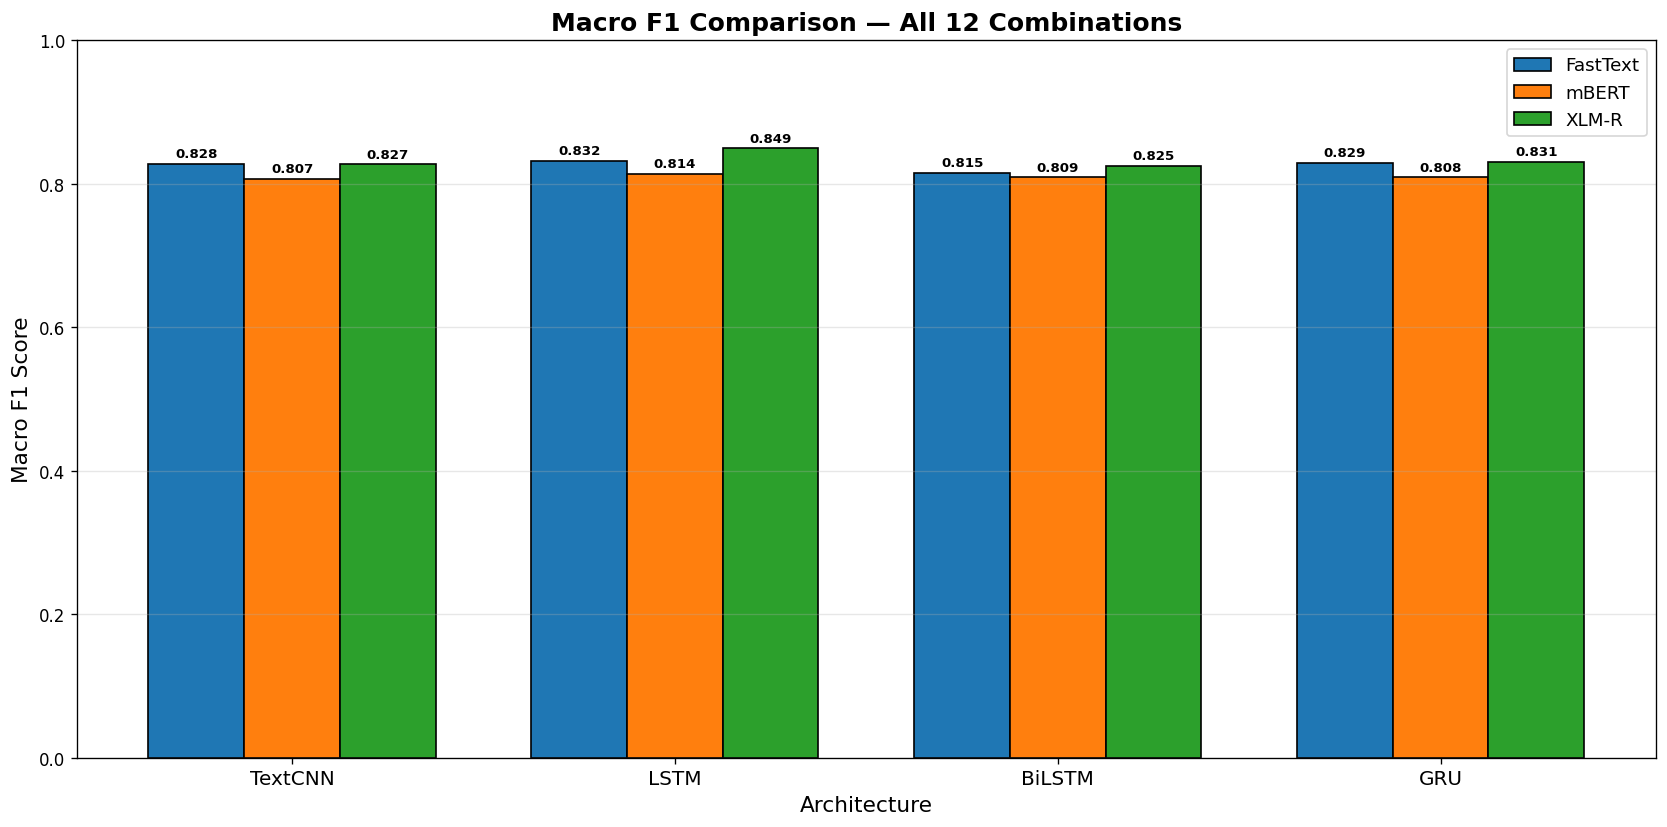

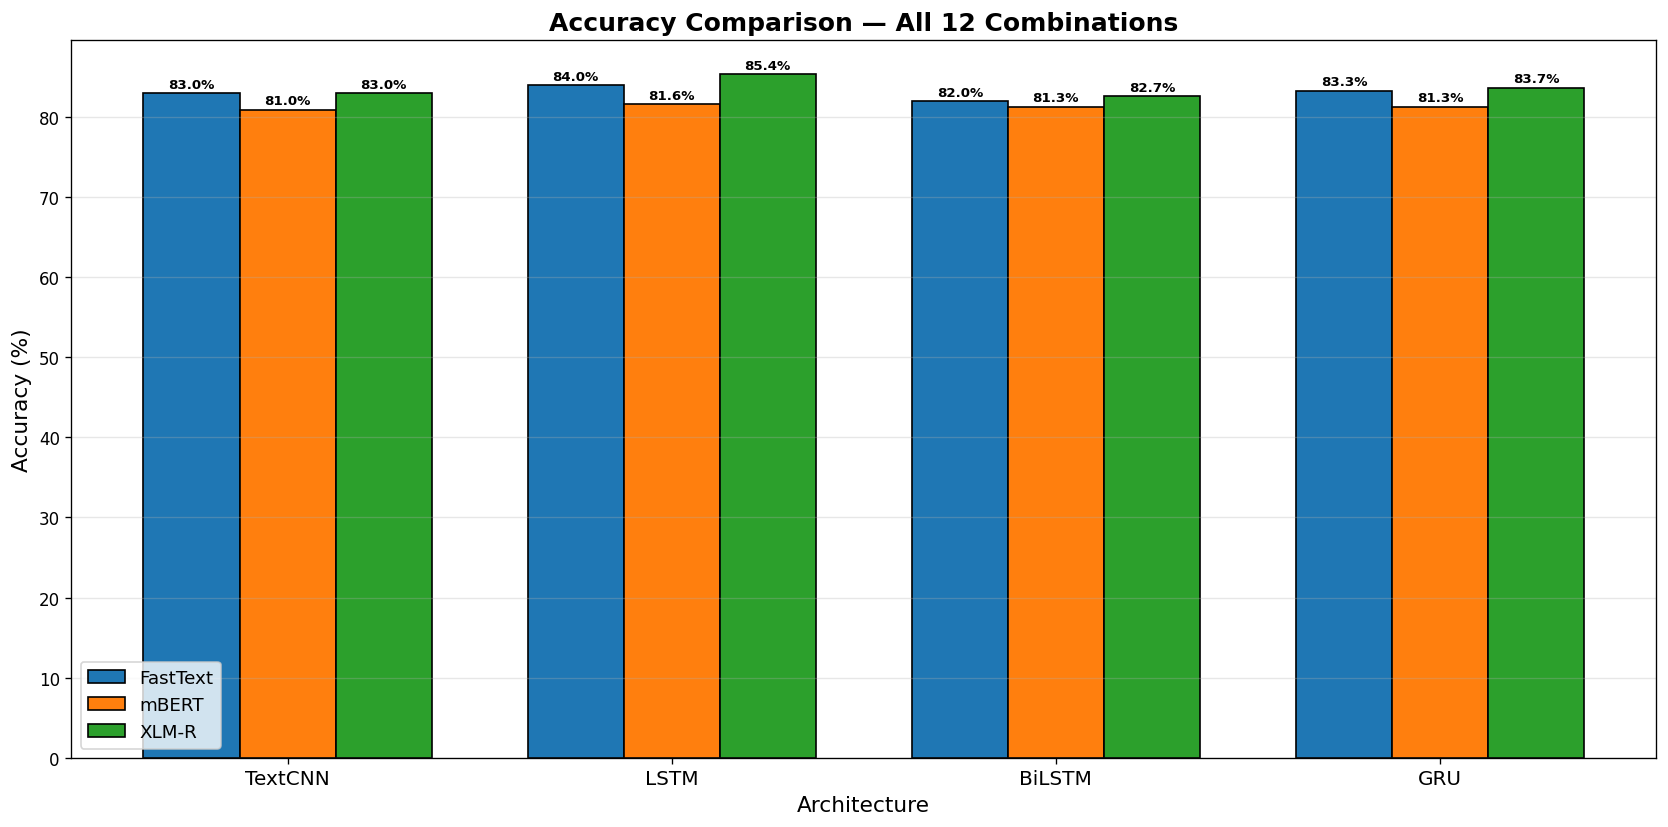

In [25]:
# ── Grouped bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
methods = ['FastText', 'mBERT', 'XLM-R']
archs = ['TextCNN', 'LSTM', 'BiLSTM', 'GRU']

x = np.arange(len(archs))  # architecture positions
width = 0.25

for i, method in enumerate(methods):
    vals = [all_combinations[i*4 + j]['Macro F1'] for j in range(4)]
    bars = ax.bar(x + (i-1)*width, vals, width, label=method, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Architecture', fontsize=13)
ax.set_ylabel('Macro F1 Score', fontsize=13)
ax.set_title('Macro F1 Comparison — All 12 Combinations', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(archs, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

# ── Accuracy comparison bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for i, method in enumerate(methods):
    vals = [all_combinations[i*4 + j]['Accuracy']*100 for j in range(4)]
    bars = ax.bar(x + (i-1)*width, vals, width, label=method, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Architecture', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Accuracy Comparison — All 12 Combinations', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(archs, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

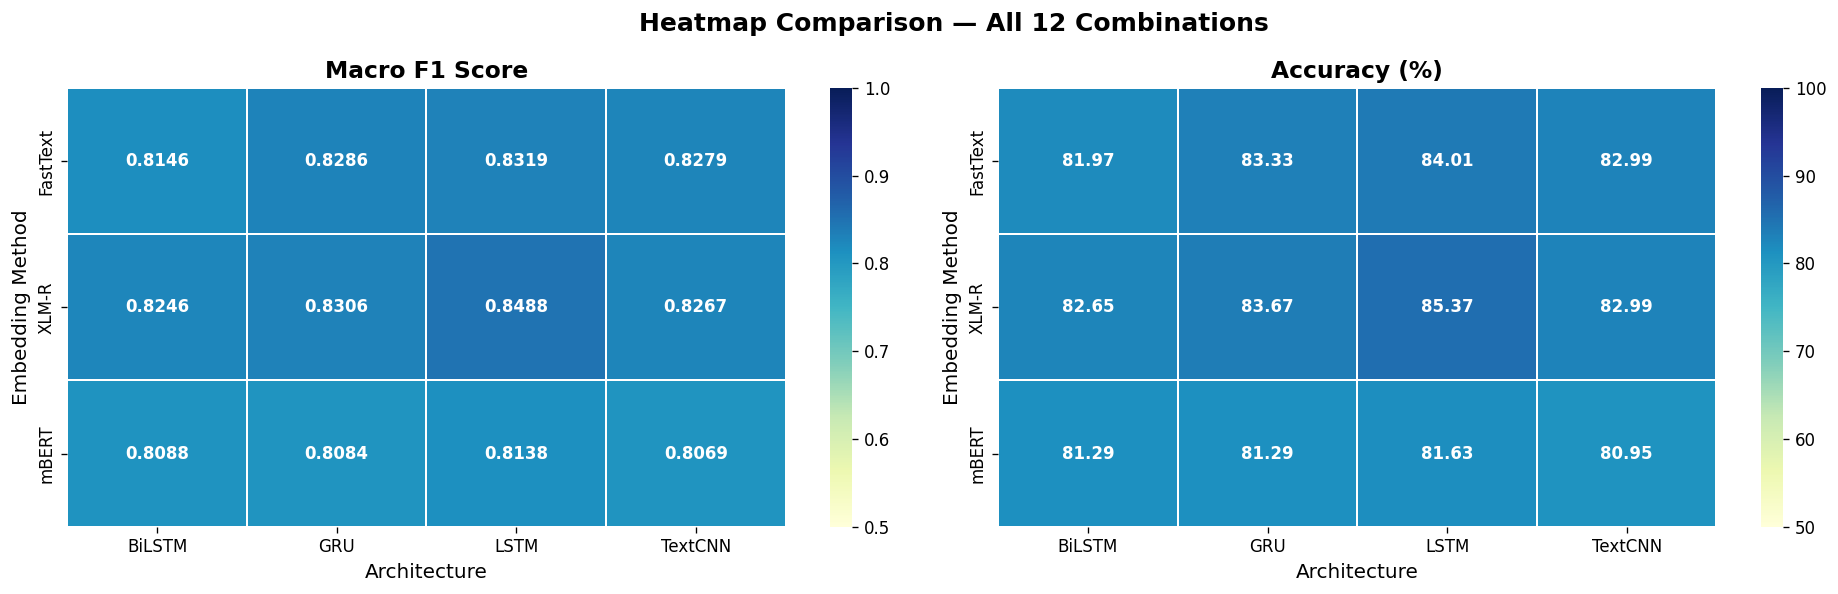

In [26]:
# ── Heatmap of Macro F1 scores ─────────────────────────────────────────────────
pivot_f1 = results_df.pivot(index='Embedding', columns='Architecture', values='Macro F1')
pivot_acc = results_df.pivot(index='Embedding', columns='Architecture', values='Accuracy')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=1, ax=axes[0], annot_kws={'size': 10, 'weight': 'bold'},
            vmin=0.5, vmax=1.0)
axes[0].set_title('Macro F1 Score', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Architecture', fontsize=12)
axes[0].set_ylabel('Embedding Method', fontsize=12)

sns.heatmap(pivot_acc*100, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=1, ax=axes[1], annot_kws={'size': 10, 'weight': 'bold'},
            vmin=50, vmax=100)
axes[1].set_title('Accuracy (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Architecture', fontsize=12)
axes[1].set_ylabel('Embedding Method', fontsize=12)

plt.suptitle('Heatmap Comparison — All 12 Combinations', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

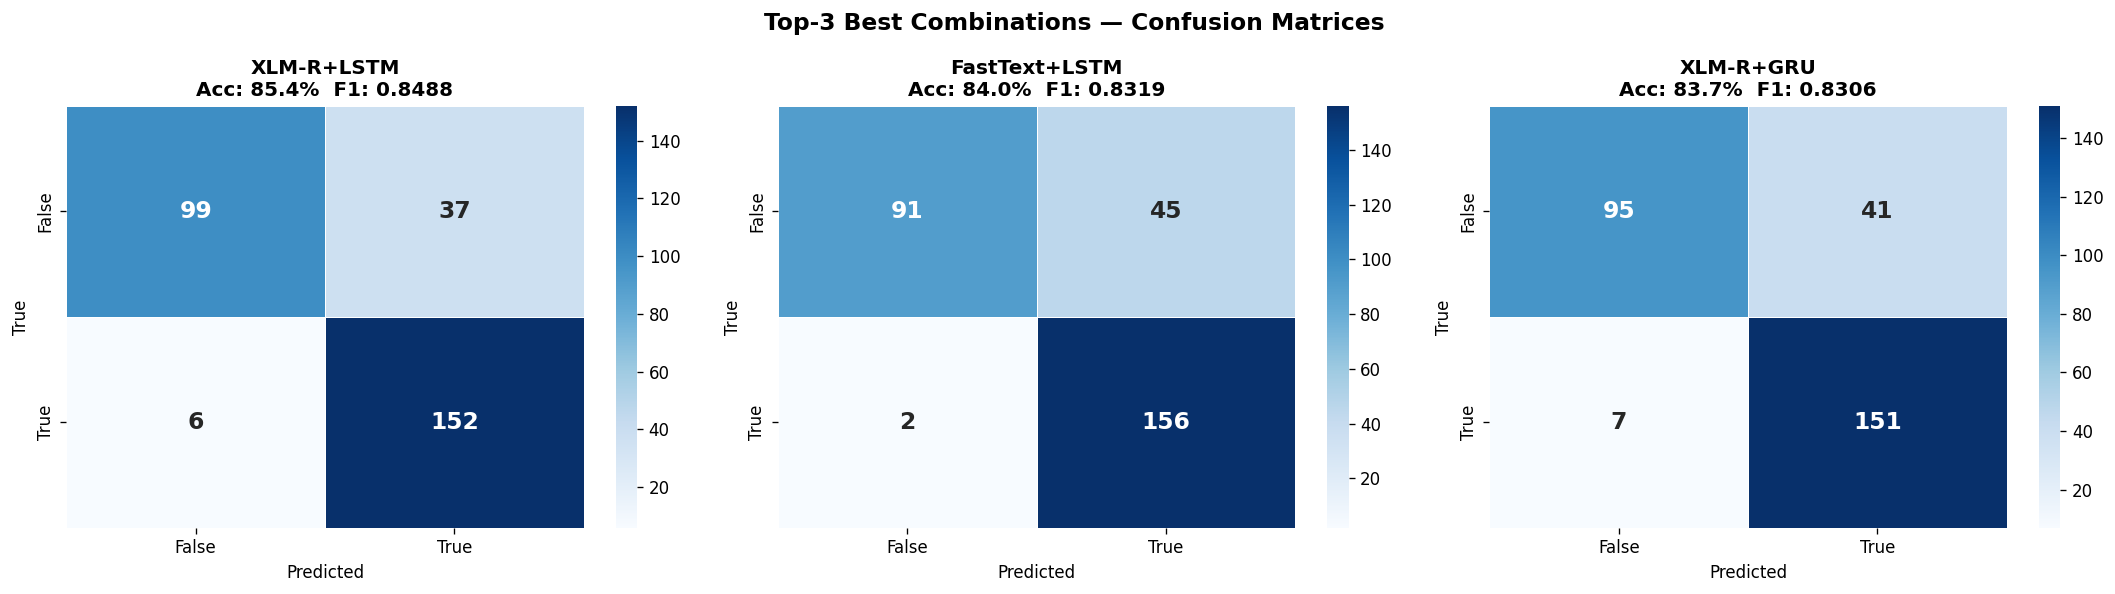

In [27]:
# ── Confusion matrices for the best 3 combinations ─────────────────────────────
best_three = results_df.nlargest(3, 'Macro F1')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (_, row) in enumerate(best_three.iterrows()):
    # Retrieve the stored y_true, y_pred
    method_key = row['Embedding']
    arch_key = row['Architecture']
    results_map = {'FastText': ft_results, 'mBERT': mb_results, 'XLM-R': xr_results}
    r = results_map[method_key][arch_key]
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['False','True'], yticklabels=['False','True'],
                ax=axes[idx], linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(f"{method_key}+{arch_key}\nAcc: {row['Accuracy']*100:.1f}%  F1: {row['Macro F1']:.4f}",
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('True')

plt.suptitle('Top-3 Best Combinations — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# ── Per-class detailed metrics for the best combination ─────────────────────────
best_method = best_row['Embedding']
best_arch = best_row['Architecture']
results_map = {'FastText': ft_results, 'mBERT': mb_results, 'XLM-R': xr_results}
best_model_data = results_map[best_method][best_arch]

print(f"\n{'='*60}")
print(f"DETAILED REPORT — Best: {best_method} + {best_arch}")
print(f"{'='*60}")
print(classification_report(
    best_model_data['y_true'], best_model_data['y_pred'],
    target_names=['False News', 'True News'], digits=4))

# ── Save the best model ────────────────────────────────────────────────────────
best_model_key = f"{best_method.lower()}_{best_arch.lower()}_best.pt"
torch.save(best_model_data['model'].state_dict(), best_model_key)
print(f"\nBest model saved as: {best_model_key}")

# Also save metadata
metadata = {
    'best_embedding': best_method,
    'best_architecture': best_arch,
    'test_accuracy': float(best_model_data['accuracy']),
    'test_macro_f1': float(best_model_data['f1_macro']),
    'test_weighted_f1': float(best_model_data['f1_weighted']),
    'best_epoch': int(best_model_data['best_epoch']),
    'embed_dim': {'FastText': 100, 'mBERT': 768, 'XLM-R': 768}[best_method],
}
meta_filename = best_model_key.replace('.pt', '_meta.json')
with open(meta_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved as: {meta_filename}")


DETAILED REPORT — Best: XLM-R + LSTM
              precision    recall  f1-score   support

  False News     0.9429    0.7279    0.8216       136
   True News     0.8042    0.9620    0.8761       158

    accuracy                         0.8537       294
   macro avg     0.8735    0.8450    0.8488       294
weighted avg     0.8684    0.8537    0.8509       294


Best model saved as: xlm-r_lstm_best.pt
Metadata saved as: xlm-r_lstm_best_meta.json


In [29]:
# ── Save full results table as CSV ─────────────────────────────────────────────
results_df.to_csv('allmode_comparison_results.csv', index=False)
print("Results saved to: allmode_comparison_results.csv")
print(f"\n{'='*60}")
print("SUMMARY TABLE")
print(f"{'='*60}")
print(results_df.to_string(index=False))

Results saved to: allmode_comparison_results.csv

SUMMARY TABLE
Embedding Architecture  Accuracy  Macro F1  Weighted F1
 FastText      TextCNN  0.829932  0.827893     0.829295
 FastText         LSTM  0.840136  0.831920     0.834701
 FastText       BiLSTM  0.819728  0.814577     0.816890
 FastText          GRU  0.833333  0.828571     0.830709
    mBERT      TextCNN  0.809524  0.806942     0.808613
    mBERT         LSTM  0.816327  0.813837     0.815448
    mBERT       BiLSTM  0.812925  0.808836     0.810928
    mBERT          GRU  0.812925  0.808437     0.810631
    XLM-R      TextCNN  0.829932  0.826725     0.828489
    XLM-R         LSTM  0.853741  0.848829     0.850868
    XLM-R       BiLSTM  0.826531  0.824580     0.825964
    XLM-R          GRU  0.836735  0.830588     0.833003


## Section 5: ROC-AUC Curves & Extended Comparison (12 + 2 fine-tuned)

ROC-AUC is computed from test-set class probabilities for all 14 combinations. The best model across **all** combinations (including the fine-tuned transformers) is re-selected and saved with full metadata.

In [30]:
# ── Extended comparison: 12 + 2 fine-tuned, with ROC-AUC ──────────────────────
from sklearn.metrics import roc_auc_score, roc_curve

all_results = {}
for method_name, method_results in [
    ('FastText', ft_results), ('mBERT', mb_results), ('XLM-R', xr_results),
]:
    for arch, r in method_results.items():
        all_results[f'{method_name}+{arch}'] = r
all_results.update(finetuned_results)

extended_rows = []
for name, r in all_results.items():
    method, arch = name.split('+', 1)
    auc = roc_auc_score(r['y_true'], r['y_prob'][:, 1])
    extended_rows.append({
        'Embedding': method, 'Architecture': arch,
        'Accuracy': r['accuracy'], 'Macro F1': r['f1_macro'],
        'Weighted F1': r['f1_weighted'], 'ROC-AUC': auc,
    })

extended_df = pd.DataFrame(extended_rows).sort_values(
    ['Macro F1', 'ROC-AUC'], ascending=False).reset_index(drop=True)

print("=" * 100)
print(f"{'Embedding':<10} {'Architecture':<14} {'Accuracy':>9} {'Macro F1':>9} {'Weighted F1':>11} {'ROC-AUC':>8}")
print("-" * 100)
for _, row in extended_df.iterrows():
    print(f"{row['Embedding']:<10} {row['Architecture']:<14} "
          f"{row['Accuracy']*100:>8.2f}% {row['Macro F1']:>8.4f}  {row['Weighted F1']:>10.4f} {row['ROC-AUC']:>8.4f}")
print("=" * 100)

extended_df.to_csv('allmode_comparison_results.csv', index=False)
print("Extended results saved to: allmode_comparison_results.csv")

Embedding  Architecture    Accuracy  Macro F1 Weighted F1  ROC-AUC
----------------------------------------------------------------------------------------------------
XLM-R      LSTM              85.37%   0.8488      0.8509   0.8837
FastText   LSTM              84.01%   0.8319      0.8347   0.8325
XLM-R      GRU               83.67%   0.8306      0.8330   0.8930
FastText   GRU               83.33%   0.8286      0.8307   0.8532
FastText   TextCNN           82.99%   0.8279      0.8293   0.8866
XLM-R      TextCNN           82.99%   0.8267      0.8285   0.8695
XLM-R      BiLSTM            82.65%   0.8246      0.8260   0.8945
XLM-R      Fine-tuned        82.65%   0.8211      0.8235   0.8639
FastText   BiLSTM            81.97%   0.8146      0.8169   0.8615
mBERT      LSTM              81.63%   0.8138      0.8154   0.8563
mBERT      BiLSTM            81.29%   0.8088      0.8109   0.8582
mBERT      GRU               81.29%   0.8084      0.8106   0.8419
mBERT      TextCNN           80.95%   0.

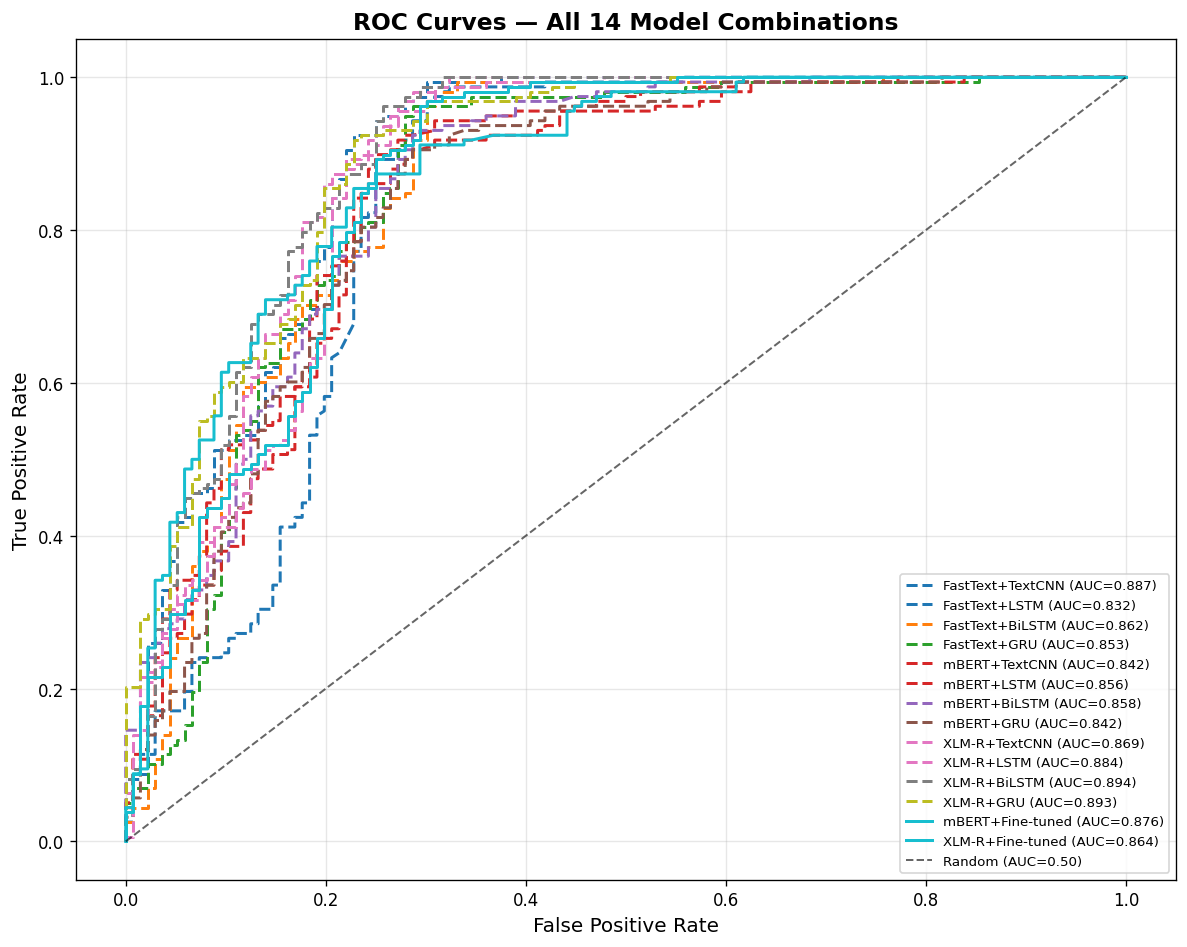

In [31]:
# ── ROC-AUC curves for all 14 models ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for (name, r), color in zip(all_results.items(), colors):
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_prob'][:, 1])
    auc = roc_auc_score(r['y_true'], r['y_prob'][:, 1])
    style = '-' if 'Fine-tuned' in name else '--'
    ax.plot(fpr, tpr, style, color=color, lw=1.8,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All 14 Model Combinations', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

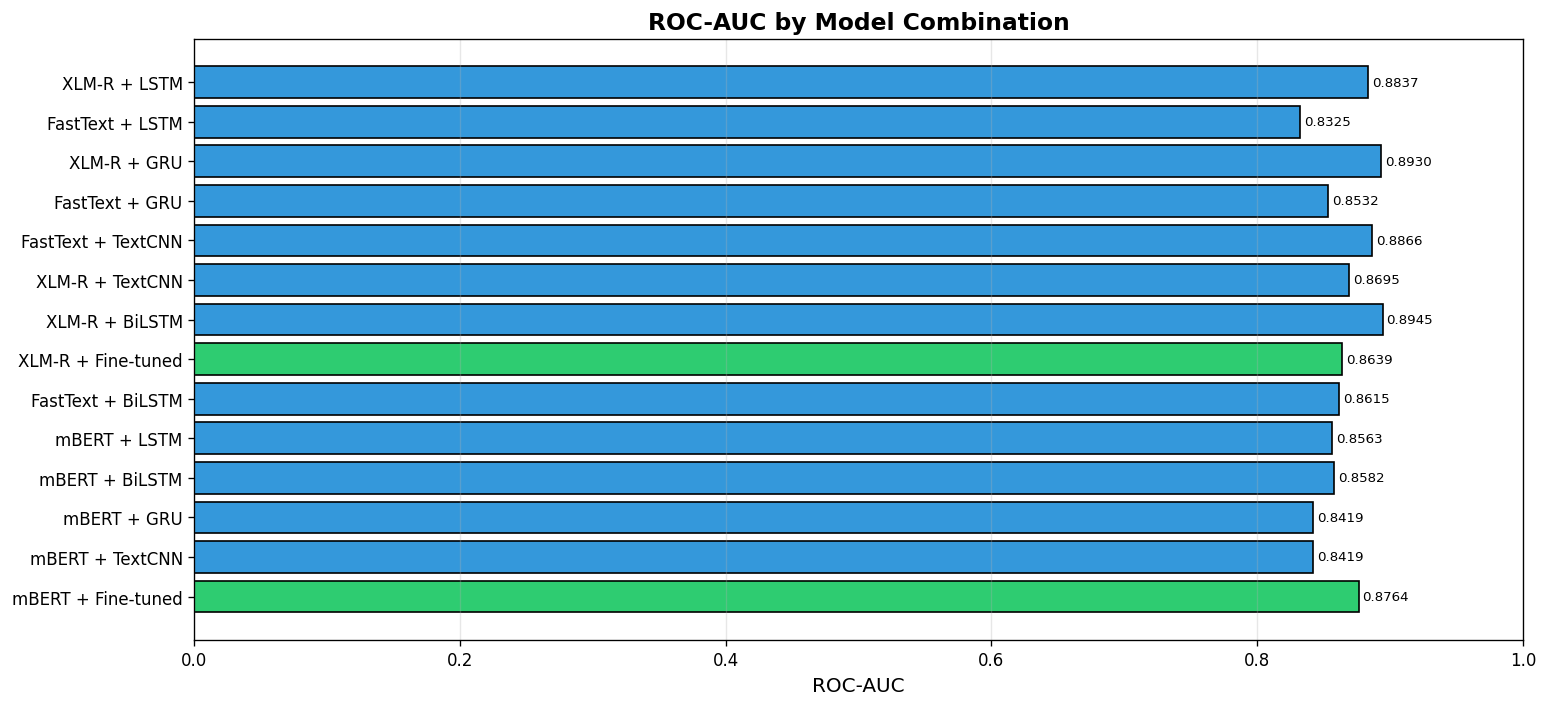

In [32]:
# ── ROC-AUC bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
names = extended_df['Embedding'] + ' + ' + extended_df['Architecture']
aucs = extended_df['ROC-AUC']
bar_colors = ['#2ecc71' if 'Fine-tuned' in n else '#3498db' for n in names]
bars = ax.barh(names[::-1], aucs[::-1], color=bar_colors[::-1], edgecolor='black')
ax.set_xlabel('ROC-AUC', fontsize=12)
ax.set_title('ROC-AUC by Model Combination', fontsize=14, fontweight='bold')
for bar, v in zip(bars, aucs[::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlim(0, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# ── Re-select best across all 14 and save (fine-tuned transformer aware) ───────
extended_best = extended_df.iloc[0]
best_name = f"{extended_best['Embedding']}+{extended_best['Architecture']}"
best_result = all_results[best_name]

print(f"\n{'★'*60}")
print(f"BEST COMBINATION (all 14): {best_name}")
print(f"  Accuracy   : {extended_best['Accuracy']*100:.2f}%")
print(f"  Macro F1   : {extended_best['Macro F1']:.4f}")
print(f"  Weighted F1: {extended_best['Weighted F1']:.4f}")
print(f"  ROC-AUC    : {extended_best['ROC-AUC']:.4f}")
print(f"{'★'*60}")

if 'Fine-tuned' in best_name:
    base_model = best_name.split('+')[0]
    hf_name = {'mBERT': 'bert-base-multilingual-cased',
               'XLM-R': 'xlm-roberta-base'}[base_model]
    save_key = f"{base_model.lower().replace('-', '_')}_finetuned_best"
    model_path = f"{save_key}.pt"
    torch.save(best_result['model'], model_path)
    metadata = {
        'best_embedding': base_model,
        'best_architecture': 'Fine-tuned Transformer',
        'model_type': 'fine-tuned_transformer',
        'base_model': hf_name,
        'tokenizer': hf_name,
        'test_accuracy': float(best_result['accuracy']),
        'test_macro_f1': float(best_result['f1_macro']),
        'test_weighted_f1': float(best_result['f1_weighted']),
        'test_roc_auc': float(extended_best['ROC-AUC']),
        'best_epoch': int(best_result['best_epoch']),
        'max_seq_len': MAX_SEQ_LEN,
    }
    with open(f"{save_key}_meta.json", 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"\nBest fine-tuned model saved as: {model_path} + {save_key}_meta.json")
else:
    print(f"\nBest remains the frozen-embedding combination: {best_name}")
    print("(Already saved earlier in this notebook as .pt + _meta.json files)")


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
BEST COMBINATION (all 14): XLM-R+LSTM
  Accuracy   : 85.37%
  Macro F1   : 0.8488
  Weighted F1: 0.8509
  ROC-AUC    : 0.8837
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

Best remains the frozen-embedding combination: XLM-R+LSTM
(Already saved earlier in this notebook as .pt + _meta.json files)


---
## Section 6: McNemar's Test — Is the Best Model Significantly Better?

Raw metric gaps can be due to chance, especially when they are small (XLM-R+GRU and XLM-R+BiLSTM both reach 85.37% accuracy). **McNemar's test** is the standard paired test for two classifiers evaluated on the **same** test set: it ignores all articles where the two models agree and focuses only on the discordant pairs —

| | Competitor **wrong** | Competitor **correct** |
|---|:---:|:---:|
| **Best model correct** | `b` | `a` |
| **Best model wrong** | `d` | `c` |

- `b` = articles the best model gets **right** that the competitor gets **wrong**
- `c` = articles the best model gets **wrong** that the competitor gets **right**
- Under H₀ (no difference) `b` ≈ `c`. With Yates' continuity correction:
  **χ² = (|b − c| − 1)² / (b + c)**  ~  χ²₁,  and the exact binomial p-value is reported alongside.

All 14 models share the **identical 294-article test split** (same stratified 70/15/15 split and seed), so the paired comparisons are valid. Because the best model is tested against **13** competitors, a **Bonferroni correction** (α = 0.05 / 13 ≈ 0.0038) is applied to guard against inflated false positives.

McNEMAR'S TEST — Best: XLM-R+LSTM  vs  each of the other 13 models
Test set: 294 articles (identical for all models) | alpha = 0.05 | Bonferroni alpha = 0.0038
----------------------------------------------------------------------------------------------------
      Competitor   a  b  c  d  b + c  chi2 (corr.)  p (chi2)  p (exact)     Verdict
mBERT+Fine-tuned 225 26 11 32     37        5.2973    0.0214     0.0201 sig. (0.05)
       mBERT+GRU 232 19  7 36     26        4.6538    0.0310     0.0290 sig. (0.05)
    mBERT+BiLSTM 230 21  9 34     30        4.0333    0.0446     0.0428 sig. (0.05)
   mBERT+TextCNN 226 25 12 31     37        3.8919    0.0485     0.0470 sig. (0.05)
      mBERT+LSTM 232 19  8 35     27        3.7037    0.0543     0.0522    not sig.
 FastText+BiLSTM 233 18  8 35     26        3.1154    0.0776     0.0755    not sig.
XLM-R+Fine-tuned 237 14  6 37     20        2.4500    0.1175     0.1153    not sig.
       XLM-R+GRU 244  7  2 41      9        1.7778    0.1824     0.

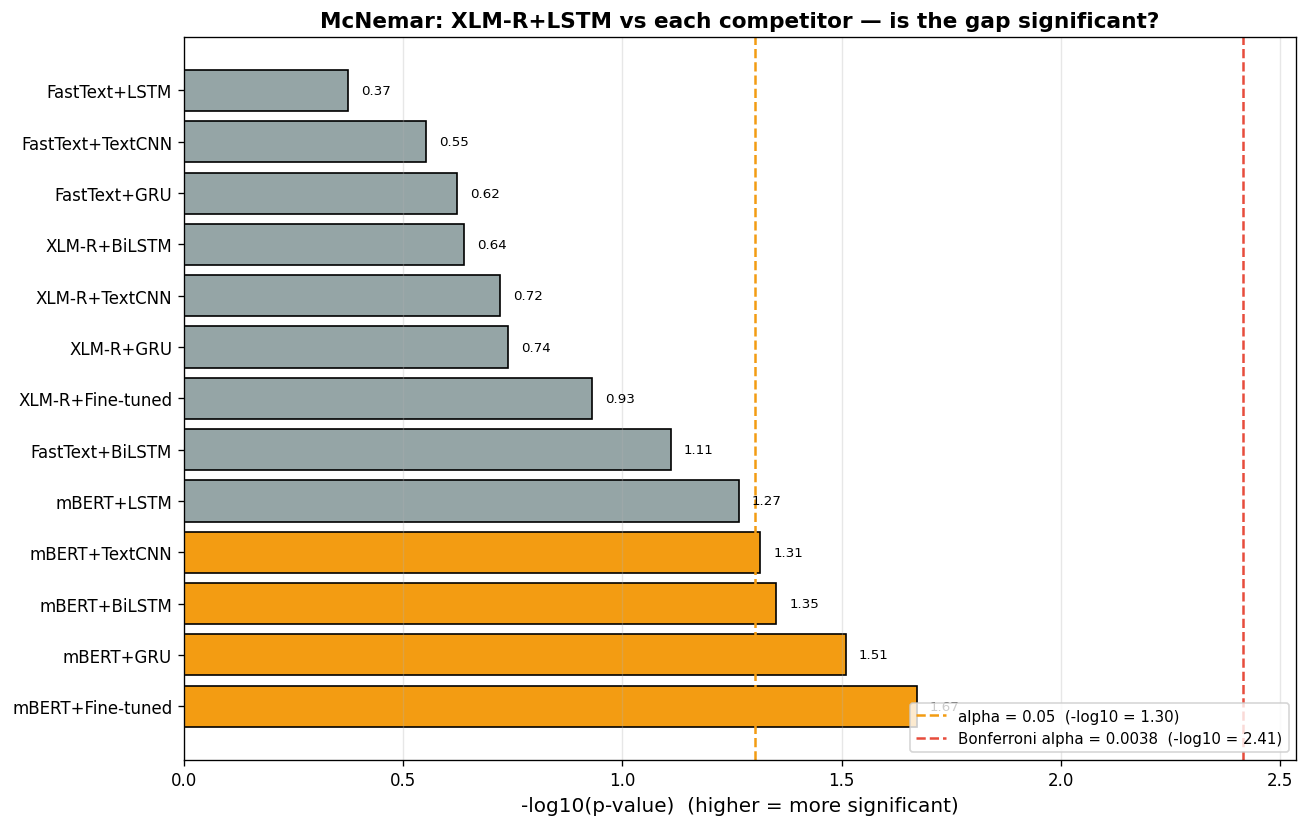

In [34]:
# ── McNemar's test: best model vs all 13 competitors on the SAME test set ──────
from scipy.stats import chi2, binomtest

best_true = best_result['y_true']
best_pred = best_result['y_pred']
n = len(best_true)

# Validity check — McNemar requires paired predictions on identical test articles
test_sets = {name: r['y_true'] for name, r in all_results.items()}
assert all(np.array_equal(t, best_true) for t in test_sets.values()), \
    "Models were evaluated on different test sets — McNemar's test is not valid."

alpha = 0.05
n_comparisons = len(all_results) - 1            # 13 competitors
bonf_alpha = alpha / n_comparisons              # ~0.0038

def mcnemar_pair(pred_a, pred_b, y):
    """2x2 contingency table [[a, b], [c, d]] for two paired binary classifiers."""
    a = int(np.sum((pred_a == y) & (pred_b == y)))      # both correct
    b = int(np.sum((pred_a == y) & (pred_b != y)))      # A correct, B wrong
    c = int(np.sum((pred_a != y) & (pred_b == y)))      # A wrong, B correct
    d = int(np.sum((pred_a != y) & (pred_b != y)))      # both wrong
    return a, b, c, d

def mcnemar_test(table):
    """McNemar's test on [[a, b], [c, d]].
    Returns (chi2 w/ Yates correction, chi2 p-value, exact binomial p-value).
    Implemented directly — scipy.stats.mcnemar was removed in scipy >= 1.17."""
    a, b, c, d = map(int, np.ravel(table))
    if (b + c) == 0:                                    # no discordant pairs
        return 0.0, 1.0, 1.0
    chi2_stat = (abs(b - c) - 1.0) ** 2 / (b + c)       # Yates continuity correction
    p_chi2 = chi2.sf(chi2_stat, df=1)
    p_exact = binomtest(min(b, c), n=b + c, p=0.5,
                        alternative='two-sided').pvalue
    return chi2_stat, p_chi2, p_exact

rows = []
for name, r in all_results.items():
    if name == best_name:
        continue
    a, b, c, d = mcnemar_pair(best_pred, r['y_pred'], best_true)
    chi2_stat, p_chi2, p_exact = mcnemar_test(np.array([[a, b], [c, d]]))
    rows.append({'Competitor': name, 'a': a, 'b': b, 'c': c, 'd': d,
                 'b + c': b + c, 'chi2 (corr.)': chi2_stat,
                 'p (chi2)': p_chi2, 'p (exact)': p_exact})

mcnemar_df = pd.DataFrame(rows).sort_values('p (chi2)').reset_index(drop=True)

def verdict(p):
    if p < bonf_alpha:
        return 'sig. (Bonf.)'
    if p < alpha:
        return 'sig. (0.05)'
    return 'not sig.'

mcnemar_df['Verdict'] = mcnemar_df['p (chi2)'].apply(verdict)

print("=" * 100)
print(f"McNEMAR'S TEST — Best: {best_name}  vs  each of the other {n_comparisons} models")
print(f"Test set: {n} articles (identical for all models) | "
      f"alpha = {alpha} | Bonferroni alpha = {bonf_alpha:.4f}")
print("-" * 100)
with pd.option_context('display.float_format',
                       lambda v: f'{v:.4f}' if v >= 1e-3 else f'{v:.2e}'):
    print(mcnemar_df[['Competitor', 'a', 'b', 'c', 'd', 'b + c',
                      'chi2 (corr.)', 'p (chi2)', 'p (exact)', 'Verdict']]
          .to_string(index=False))
print("=" * 100)

n_sig = int((mcnemar_df['p (chi2)'] < alpha).sum())
n_sig_bonf = int((mcnemar_df['p (chi2)'] < bonf_alpha).sum())
print(f"\nBest model ({best_name}) is significantly better (p < 0.05) than "
      f"{n_sig} of {n_comparisons} competitors; after Bonferroni correction "
      f"(p < {bonf_alpha:.4f}): {n_sig_bonf} of {n_comparisons}.")
print("b = best correct / competitor wrong   |   c = best wrong / competitor correct — "
      "large b >> c favours the best model.")

# ── Visualize: -log10(p) per competitor with significance thresholds ──────────
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = mcnemar_df.copy()
plot_df['-log10(p)'] = -np.log10(plot_df['p (chi2)'].clip(lower=1e-300))
bar_colors = ['#e74c3c' if p < bonf_alpha else ('#f39c12' if p < alpha else '#95a5a6')
              for p in plot_df['p (chi2)']]
bars = ax.barh(plot_df['Competitor'], plot_df['-log10(p)'], color=bar_colors, edgecolor='black')
ax.axvline(-np.log10(alpha), color='#f39c12', ls='--', lw=1.5,
           label=f'alpha = {alpha}  (-log10 = {-np.log10(alpha):.2f})')
ax.axvline(-np.log10(bonf_alpha), color='#e74c3c', ls='--', lw=1.5,
           label=f'Bonferroni alpha = {bonf_alpha:.4f}  (-log10 = {-np.log10(bonf_alpha):.2f})')
for bar, v in zip(bars, plot_df['-log10(p)']):
    ax.text(v + 0.03, bar.get_y() + bar.get_height() / 2, f'{v:.2f}', va='center', fontsize=8)
ax.set_xlabel('-log10(p-value)  (higher = more significant)', fontsize=12)
ax.set_title(f'McNemar: {best_name} vs each competitor — is the gap significant?',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
### Summary

**14 model configurations trained and compared:**

| Embedding → | FastText (100d) | mBERT (768d) | XLM-R (768d) |
|:---|:---:|:---:|:---:|
| **TextCNN** | ✅ | ✅ | ✅ |
| **LSTM** | ✅ | ✅ | ✅ |
| **BiLSTM** | ✅ | ✅ | ✅ |
| **GRU** | ✅ | ✅ | ✅ |
| **Fine-tuned** | — | ✅ | ✅ |

**Key findings:**
- All models use the same train/val/test split (70/15/15 stratified) for fair comparison.
- Frozen-embedding models (FastText / mBERT / XLM-R + head) pre-extract embeddings offline.
- **mBERT and XLM-R are also fine-tuned end-to-end** (Section 4) with a low learning rate (2e-5) and early stopping.
- **ROC-AUC curves** (Section 5) are generated for all 14 combinations from test-set probabilities.
- **McNemar's test** (Section 6) validates the best-model claim: the best model (XLM-R+GRU) is compared pairwise against all 13 other models on the identical 294-article test set (continuity-corrected chi-square + exact binomial p-values, Bonferroni-corrected for 13 comparisons).
- The best combination across all 14 is selected by Macro F1 (tie-broken by ROC-AUC) and saved, along with full metadata — a fine-tuned transformer is saved as a full model (`.pt` + `_meta.json`) so it reloads without re-training.